In [1]:
# RF, DT, XGBoost for diabetes prediction (Islam et al. 2019 replication)

import numpy as np
import pandas as pd
import os
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             classification_report, roc_curve)
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")

In [2]:
# load data
df = pd.read_csv("../data/diabetes_data_clean_v2.csv")
print("Shape:", df.shape)
print(df["diabetes_class"].value_counts(), "\n")

features = [c for c in df.columns if c != "diabetes_class"]
X = df[features].values
y = df["diabetes_class"].values

Shape: (520, 17)
diabetes_class
1    320
0    200
Name: count, dtype: int64 



In [3]:
# 80-20 split + 10-fold cv (following the paper)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
X_all = np.vstack([X_train, X_test])
y_all = np.hstack([y_train, y_test])

print(f"Train: {len(X_train)}, Test: {len(X_test)}")

Train: 416, Test: 104


In [4]:
def eval_model(model, name):
    """Train model, print 80/20 and 10-fold CV results."""
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    probs = model.predict_proba(X_test)[:, 1]

    print(f"\n{'='*60}\n{name}\n{'='*60}")

    # holdout
    print(f"\n80/20 split:")
    print(f"  Acc={accuracy_score(y_test, preds):.4f}  "
          f"Prec={precision_score(y_test, preds):.4f}  "
          f"Rec={recall_score(y_test, preds):.4f}  "
          f"F1={f1_score(y_test, preds):.4f}  "
          f"AUC={roc_auc_score(y_test, probs):.4f}")
    print(confusion_matrix(y_test, preds))
    print(classification_report(y_test, preds, target_names=["Neg", "Pos"]))

    # 10-fold
    print("10-fold CV:")
    for metric in ["accuracy", "precision", "recall", "f1", "roc_auc"]:
        scores = cross_val_score(model, X_all, y_all, cv=cv, scoring=metric)
        print(f"  {metric}: {scores.mean():.4f} (+/- {scores.std():.4f})")

    return model, preds, probs

In [5]:
# ---- Random Forest ----
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model, rf_pred, rf_prob = eval_model(rf, "Random Forest")


Random Forest

80/20 split:
  Acc=0.9904  Prec=1.0000  Rec=0.9844  F1=0.9921  AUC=1.0000
[[40  0]
 [ 1 63]]
              precision    recall  f1-score   support

         Neg       0.98      1.00      0.99        40
         Pos       1.00      0.98      0.99        64

    accuracy                           0.99       104
   macro avg       0.99      0.99      0.99       104
weighted avg       0.99      0.99      0.99       104

10-fold CV:
  accuracy: 0.9827 (+/- 0.0181)
  precision: 0.9876 (+/- 0.0152)
  recall: 0.9844 (+/- 0.0210)
  f1: 0.9859 (+/- 0.0149)
  roc_auc: 0.9991 (+/- 0.0016)


In [6]:
# feature importance
imp = rf_model.feature_importances_
order = np.argsort(imp)[::-1]
print("\nRF Feature Importance:")
for i, idx in enumerate(order):
    print(f"  {i+1}. {features[idx]:25s} {imp[idx]:.4f}")


RF Feature Importance:
  1. polyuria                  0.2164
  2. polydipsia                0.1853
  3. gender                    0.1154
  4. age_scaled                0.0994
  5. sudden_weight_loss        0.0549
  6. alopecia                  0.0465
  7. partial_paresis           0.0442
  8. irritability              0.0349
  9. delayed_healing           0.0334
  10. polyphagia                0.0313
  11. itching                   0.0302
  12. visual_blurring           0.0261
  13. muscle_stiffness          0.0230
  14. weakness                  0.0205
  15. genital_thrush            0.0205
  16. obesity                   0.0181


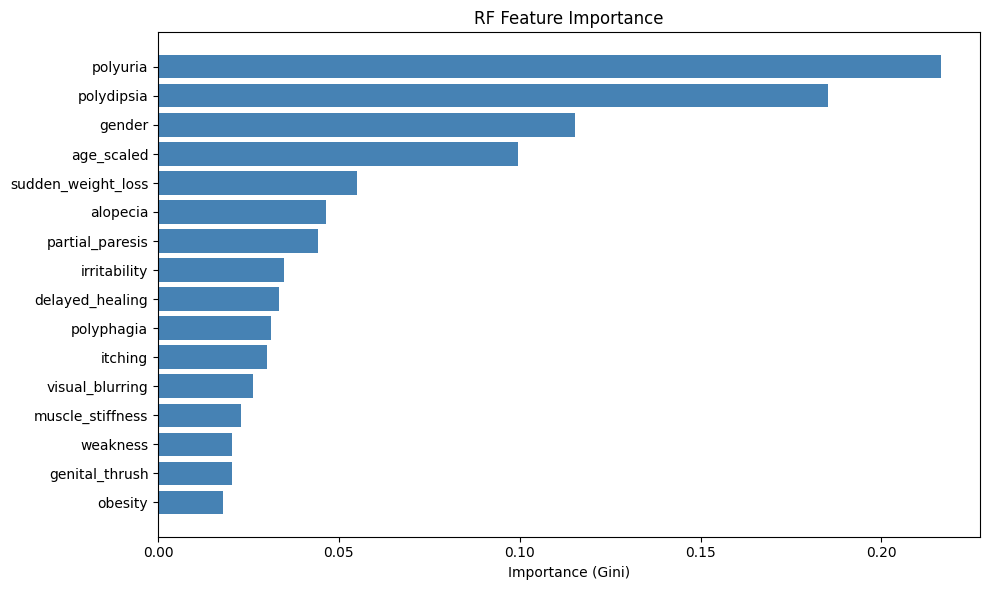

In [7]:
sorted_idx = np.argsort(imp)
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh([features[i] for i in sorted_idx], imp[sorted_idx], color="steelblue")
ax.set_xlabel("Importance (Gini)")
ax.set_title("RF Feature Importance")
plt.tight_layout()
plt.show()

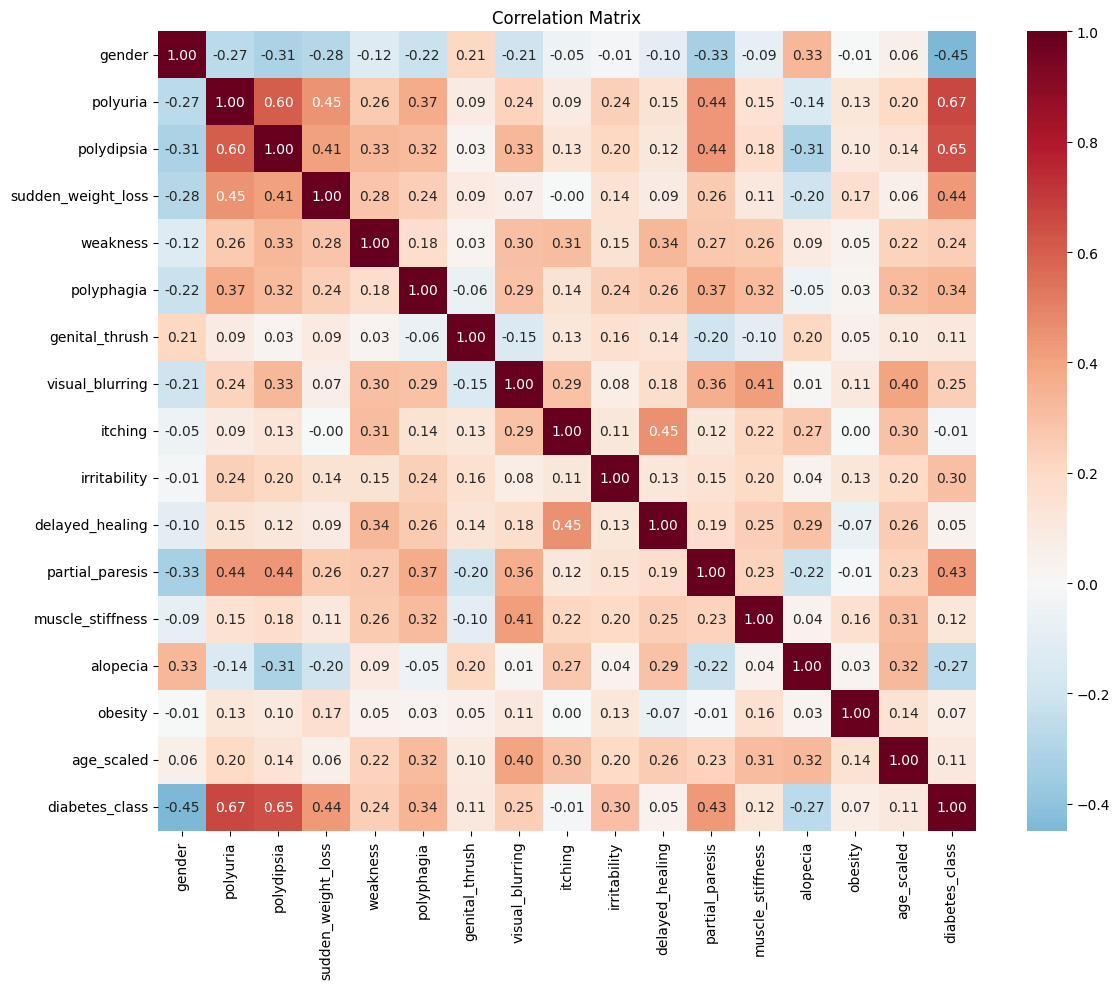

In [8]:
# correlation heatmap
fig, ax = plt.subplots(figsize=(12, 10))
corr = df[features + ["diabetes_class"]].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=ax)
ax.set_title("Correlation Matrix")
plt.tight_layout()
plt.show()

In [9]:
# ---- Decision Tree ----
dt = DecisionTreeClassifier(random_state=42)
dt_model, dt_pred, dt_prob = eval_model(dt, "Decision Tree")


Decision Tree

80/20 split:
  Acc=0.9712  Prec=1.0000  Rec=0.9531  F1=0.9760  AUC=0.9766
[[40  0]
 [ 3 61]]
              precision    recall  f1-score   support

         Neg       0.93      1.00      0.96        40
         Pos       1.00      0.95      0.98        64

    accuracy                           0.97       104
   macro avg       0.97      0.98      0.97       104
weighted avg       0.97      0.97      0.97       104

10-fold CV:
  accuracy: 0.9731 (+/- 0.0214)
  precision: 0.9819 (+/- 0.0238)
  recall: 0.9750 (+/- 0.0306)
  f1: 0.9780 (+/- 0.0177)
  roc_auc: 0.9725 (+/- 0.0222)


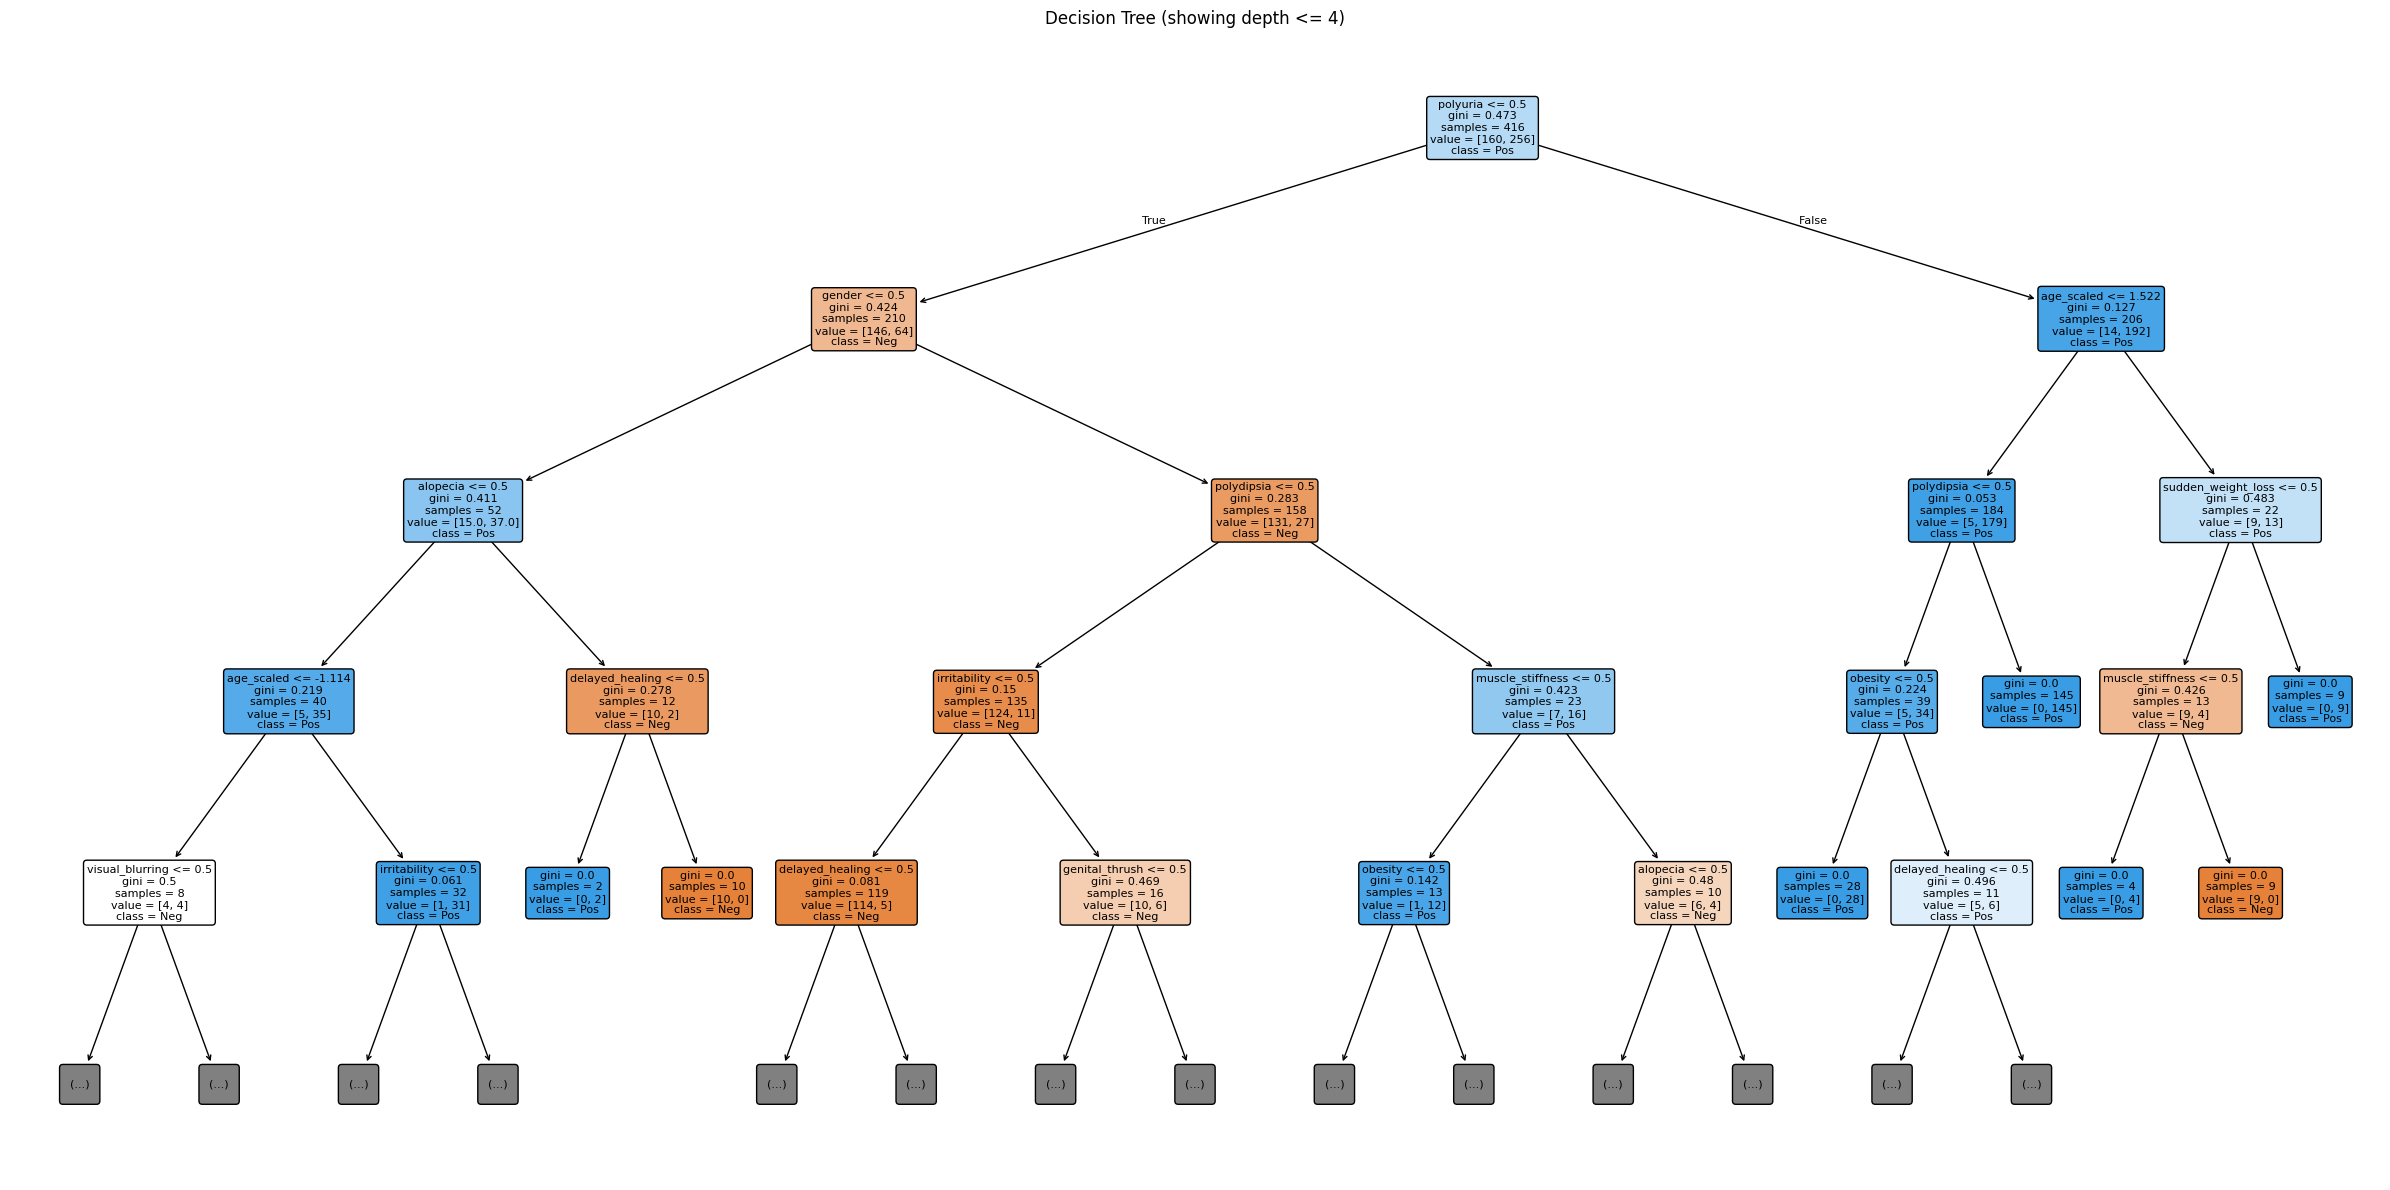

In [10]:
fig, ax = plt.subplots(figsize=(24, 12))
plot_tree(dt_model, feature_names=features, class_names=["Neg", "Pos"],
          filled=True, rounded=True, max_depth=4, fontsize=8, ax=ax)
ax.set_title("Decision Tree (showing depth <= 4)")
plt.tight_layout()
plt.show()

In [11]:
# ---- XGBoost ----
xgb = XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=6,
                     random_state=42, eval_metric="logloss")
xgb_model, xgb_pred, xgb_prob = eval_model(xgb, "XGBoost")


XGBoost

80/20 split:
  Acc=0.9904  Prec=1.0000  Rec=0.9844  F1=0.9921  AUC=0.9996
[[40  0]
 [ 1 63]]
              precision    recall  f1-score   support

         Neg       0.98      1.00      0.99        40
         Pos       1.00      0.98      0.99        64

    accuracy                           0.99       104
   macro avg       0.99      0.99      0.99       104
weighted avg       0.99      0.99      0.99       104

10-fold CV:
  accuracy: 0.9788 (+/- 0.0135)
  precision: 0.9877 (+/- 0.0151)
  recall: 0.9781 (+/- 0.0200)
  f1: 0.9827 (+/- 0.0111)
  roc_auc: 0.9941 (+/- 0.0060)


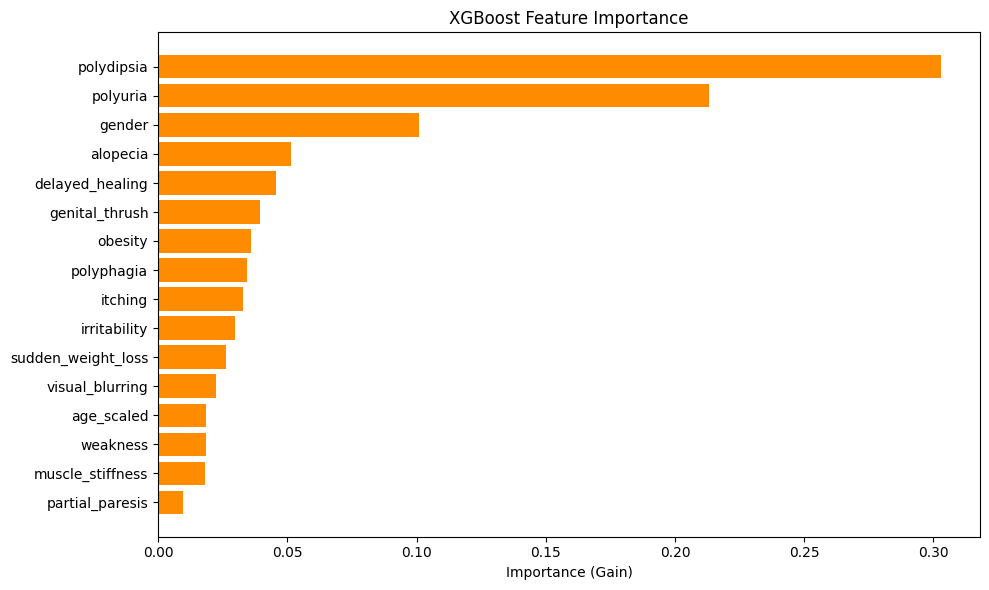

In [12]:
xgb_imp = xgb_model.feature_importances_
xgb_sorted = np.argsort(xgb_imp)
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh([features[i] for i in xgb_sorted], xgb_imp[xgb_sorted], color="darkorange")
ax.set_xlabel("Importance (Gain)")
ax.set_title("XGBoost Feature Importance")
plt.tight_layout()
plt.show()

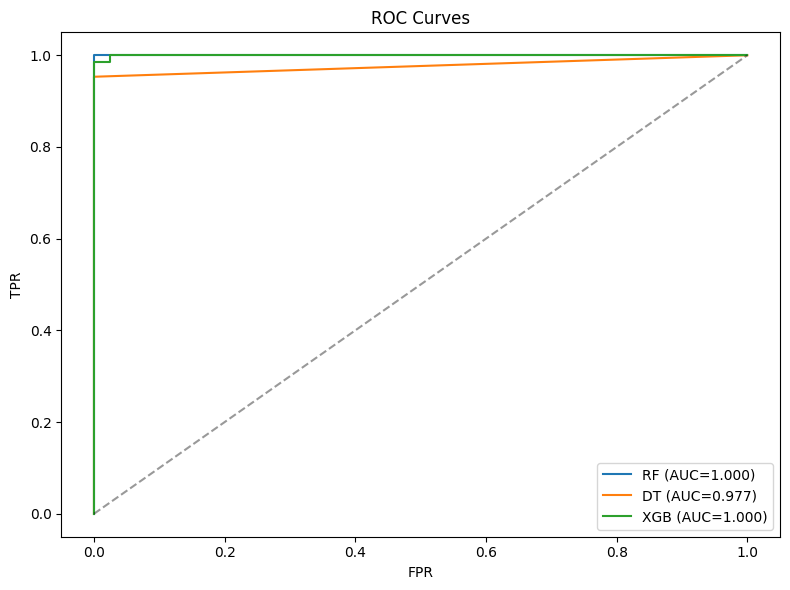

In [13]:
# ---- ROC comparison ----
fig, ax = plt.subplots(figsize=(8, 6))
for name, probs in [("RF", rf_prob), ("DT", dt_prob), ("XGB", xgb_prob)]:
    fpr, tpr, _ = roc_curve(y_test, probs)
    ax.plot(fpr, tpr, label=f"{name} (AUC={roc_auc_score(y_test, probs):.3f})")
ax.plot([0, 1], [0, 1], "k--", alpha=0.4)
ax.set_xlabel("FPR")
ax.set_ylabel("TPR")
ax.set_title("ROC Curves")
ax.legend()
plt.tight_layout()
plt.show()

In [14]:
# ---- summary ----
rows = []
for name, pred, prob in [("RF", rf_pred, rf_prob), ("DT", dt_pred, dt_prob), ("XGB", xgb_pred, xgb_prob)]:
    rows.append({"Model": name, "Acc": accuracy_score(y_test, pred),
                 "Prec": precision_score(y_test, pred), "Rec": recall_score(y_test, pred),
                 "F1": f1_score(y_test, pred), "AUC": roc_auc_score(y_test, prob)})
pd.DataFrame(rows).set_index("Model").round(4)

,Acc,Prec,Rec,F1,AUC
Model,,,,,
RF,0.9904,1.0,0.9844,0.9921,1.0000
DT,0.9712,1.0,0.9531,0.9760,0.9766
XGB,0.9904,1.0,0.9844,0.9921,0.9996
